In [2]:
# Import libraries
import numpy as np
import pandas as pd
import h5py
import polars as pl
import pickle

from statsmodels.datasets import get_rdataset

import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage
from sklearn.metrics import silhouette_score

## Load Data

In [3]:
with open('../data/pca_data.pkl', 'rb') as f:
      data = pickle.load(f)

In [4]:
data.keys()

dict_keys(['df', 'X', 'X_scaled', 'X_pca', 'pca', 'feature_cols'])

In [5]:
cs_df = data['df']
X = data['X']
X_scaled = data['X_scaled']
X_pca = data['X_pca']
pca = data['pca']
feature_cols = data['feature_cols']

X.shape, X_scaled.shape, X_pca.shape

((98, 40), (98, 40), (98, 9))

In [6]:
print(X_scaled.shape)

(98, 40)


## Perform Clustering

### Hierarchical Clustering: Complete

In [7]:
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete')
hc_comp.fit(X_scaled)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'complete'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


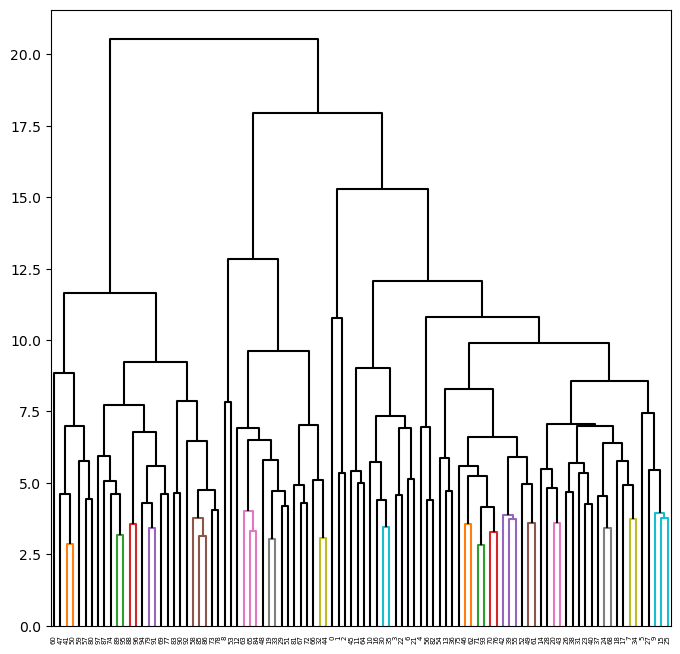

In [8]:
# Complete Linkage
linkage_comp = compute_linkage(hc_comp)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');

### Hierarchical Clustering: Average

In [9]:
hc_avg = HClust(distance_threshold=0,
                n_clusters=None,
                linkage='average');
hc_avg.fit(X_scaled)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'average'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


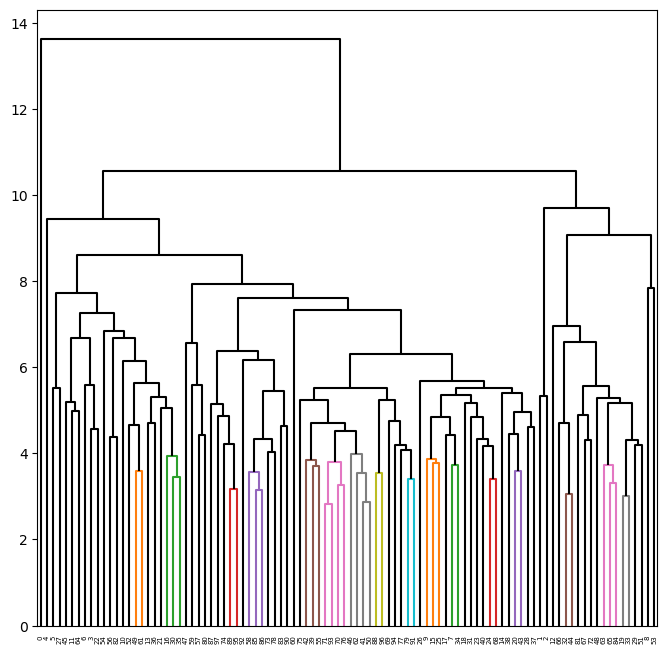

In [10]:
# Average Linkage
linkage_avg = compute_linkage(hc_avg)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_avg,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');

### Hierarchical Clustering: Single

In [11]:
hc_sing = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='single');
hc_sing.fit(X_scaled);

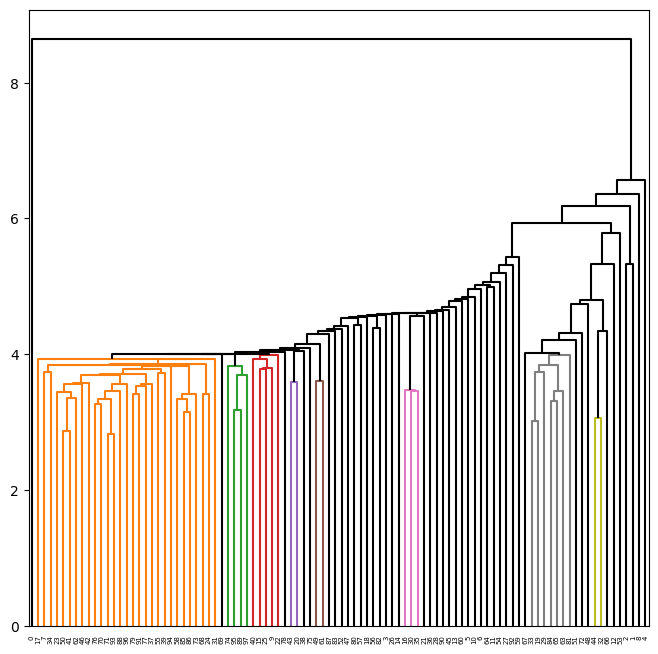

In [12]:
# Single Linkage
linkage_sing = compute_linkage(hc_sing)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_sing,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');

### Hierarchical Clustering: Ward

In [13]:
hc_ward = HClust(
    distance_threshold=0,
    n_clusters=None,
    linkage='ward'
)

hc_ward.fit(X_scaled)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


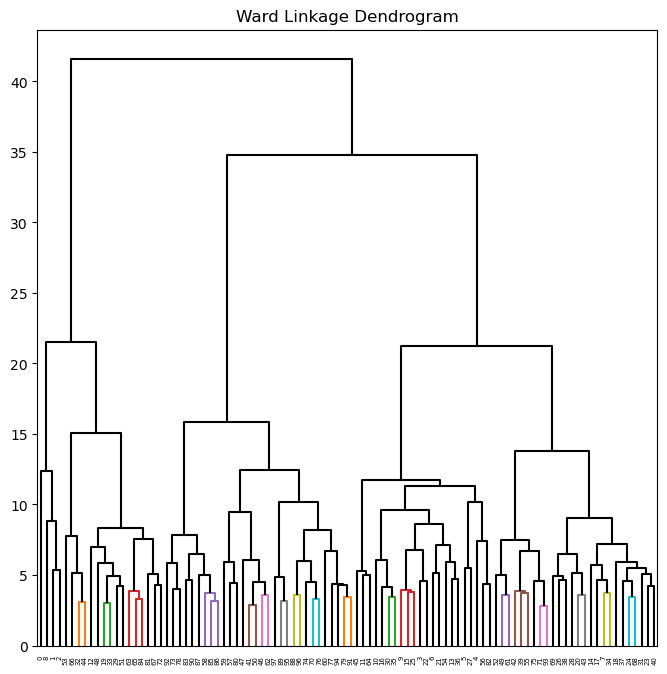

In [46]:
# Ward Linkage
linkage_ward = compute_linkage(hc_ward)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plt.title("Ward Linkage Dendrogram")
dendrogram(linkage_ward,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');

<span style="color:green"> Ward linkage was selected after comparing single, average, complete, and Ward linkage dendrograms. Single linkage showed significant chaining behavior, while average and complete linkage produced less distinct cluster separation. Ward linkage provided the clearest cluster structure and generated compact, consistent clusters by minimizing within-cluster variance during the merging process. This resulted in meaningful player groupings that were easier to interpret than the other linkage methods. </span>

## Computer silhouette scores

In [15]:
results = []

for k in range(2, 7):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append((k, score))

for k, score in results:
    print(f"k={k}: {score:.3f}")

k=2: 0.291
k=3: 0.206
k=4: 0.216
k=5: 0.154
k=6: 0.151


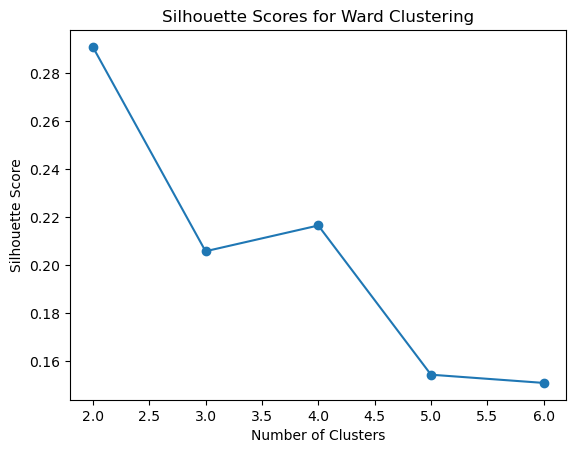

In [16]:
ks = [r[0] for r in results]
scores = [r[1] for r in results]

plt.plot(ks, scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Ward Clustering")
plt.show()

<span style="color:green"> The plot shows that silhouette score is highest for 2 clusters and for 4 clusters, and then closely followed by 3 clusters. </span>

## Tune Ward by cutting into clusters

### 2 Clusters

In [17]:
ward_cut_2 = cut_tree(linkage_ward,
                      n_clusters=2).reshape(-1)

cs_df_2c = cs_df.with_columns(
    pl.Series("Cluster2", ward_cut_2)
)

cs_df_2c.head()

player_id,player_name,player_fullname,RATING_3_0,T_RATING,CT_RATING,ROUND_SWING,DPR,KAST,MULTI_KILL,ADR,KPR,Total_kills,Headshot_pct,Total_deaths,KD_Ratio,Damage_per_Round,Grenade_dmg_per_Round,Maps_played,Rounds_played,Kills_per_round,Assists_per_round,Deaths_per_round,Saved_by_teammate_per_round,Saved_teammates_per_round,Impact_rating,total_kills_weapon,rifle_kills,rifle_pct,sniper_kills,sniper_pct,pistol_kills,pistol_pct,smg_kills,smg_pct,ak47_kills,m4a1_kills,m4a1s_kills,awp_kills,ssg08_kills,deagle_kills,glock_kills,usp_kills,sniper_kills_log,sniper_pct_log,awp_kills_log,ssg08_kills_log,Cluster2
i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,f64,i64,f64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64
21167,"""donk""","""Danil Kryshkovets""",1.41,1.46,1.38,3.72,0.66,77.8,25.1,94.5,0.9,889,61.4,652,1.36,94.5,3.6,47,985,0.9,0.23,0.66,0.13,0.15,1.64,889,722,81.2,11,1.2,142,16.0,7,0.8,514,109,68,11,0,38,33,40,2.484907,0.788457,2.484907,0.0,0
11893,"""ZywOo""","""Mathieu Herbaut""",1.36,1.38,1.35,4.03,0.55,77.6,22.3,85.1,0.86,1053,41.0,672,1.57,85.1,4.2,56,1228,0.86,0.17,0.55,0.1,0.12,1.44,1053,395,37.5,441,41.9,180,17.1,17,1.6,277,81,5,429,12,35,40,25,6.09131,3.758872,6.063785,2.564949,0
19230,"""m0NESY""","""Ilya Osipov""",1.28,1.17,1.39,3.78,0.59,76.7,20.4,81.0,0.81,823,36.3,599,1.37,81.0,3.3,45,1016,0.81,0.13,0.59,0.1,0.1,1.26,888,236,26.6,492,55.4,135,15.2,9,1.0,141,28,41,473,19,14,41,17,6.200509,4.032469,6.161207,2.995732,0
21667,"""Magnojez""","""Kirill Rodnov""",1.21,1.17,1.24,1.78,0.68,74.2,19.5,86.0,0.77,1202,52.2,1068,1.13,86.0,3.3,75,1568,0.77,0.24,0.68,0.09,0.1,1.36,1202,876,72.9,26,2.2,182,15.1,98,8.2,491,67,253,23,3,13,40,55,3.295837,1.163151,3.178054,1.386294,1
16693,"""flameZ""","""Shahar Shushan""",1.2,1.17,1.24,1.45,0.66,76.6,20.0,78.8,0.75,924,53.2,806,1.15,78.8,3.6,56,1228,0.75,0.19,0.66,0.14,0.11,1.27,924,624,67.5,2,0.2,125,13.5,165,17.9,310,273,4,2,0,16,43,35,1.098612,0.182322,1.098612,0.0,1


In [18]:
cs_df_2c.group_by("Cluster2").len()

Cluster2,len
i64,u32
1,78
0,20


In [19]:
cs_df_2c.group_by("Cluster2").agg([
    pl.mean("RATING_3_0"),
    pl.mean("KD_Ratio"),
    pl.mean("ADR"),
    pl.mean("KPR"),
    pl.mean("sniper_pct")
])

Cluster2,RATING_3_0,KD_Ratio,ADR,KPR,sniper_pct
i64,f64,f64,f64,f64,f64
0,1.106,1.214,72.6,0.7155,46.83
1,1.054744,1.01859,73.39359,0.665128,1.15


In [20]:
cs_df_2c.group_by("Cluster2").agg([
    pl.mean("awp_kills"),
    pl.mean("rifle_kills"),
    pl.mean("ak47_kills"),
    pl.mean("m4a1s_kills")
])

Cluster2,awp_kills,rifle_kills,ak47_kills,m4a1s_kills
i64,f64,f64,f64,f64
0,446.7,321.15,181.0,54.55
1,9.192308,676.102564,355.358974,161.205128


<span style="color:green"> The 2-cluster solution separates players primarily based on their use of sniper rifles. Players who are very dedicated to and are proficient with the AWP are grouped into cluster 0 with 46.8% sniper percentage and 446.7 AQP kills, while everyone else is grouped into cluster 1. </span>

### 3 Clusters

In [21]:
ward_cut_3 = cut_tree(linkage_ward,
                    n_clusters=3).reshape(-1)

cs_df_3c = cs_df.with_columns(
    pl.Series("Cluster3", ward_cut_3)
)

cs_df_3c.head()

player_id,player_name,player_fullname,RATING_3_0,T_RATING,CT_RATING,ROUND_SWING,DPR,KAST,MULTI_KILL,ADR,KPR,Total_kills,Headshot_pct,Total_deaths,KD_Ratio,Damage_per_Round,Grenade_dmg_per_Round,Maps_played,Rounds_played,Kills_per_round,Assists_per_round,Deaths_per_round,Saved_by_teammate_per_round,Saved_teammates_per_round,Impact_rating,total_kills_weapon,rifle_kills,rifle_pct,sniper_kills,sniper_pct,pistol_kills,pistol_pct,smg_kills,smg_pct,ak47_kills,m4a1_kills,m4a1s_kills,awp_kills,ssg08_kills,deagle_kills,glock_kills,usp_kills,sniper_kills_log,sniper_pct_log,awp_kills_log,ssg08_kills_log,Cluster3
i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,f64,i64,f64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64
21167,"""donk""","""Danil Kryshkovets""",1.41,1.46,1.38,3.72,0.66,77.8,25.1,94.5,0.9,889,61.4,652,1.36,94.5,3.6,47,985,0.9,0.23,0.66,0.13,0.15,1.64,889,722,81.2,11,1.2,142,16.0,7,0.8,514,109,68,11,0,38,33,40,2.484907,0.788457,2.484907,0.0,0
11893,"""ZywOo""","""Mathieu Herbaut""",1.36,1.38,1.35,4.03,0.55,77.6,22.3,85.1,0.86,1053,41.0,672,1.57,85.1,4.2,56,1228,0.86,0.17,0.55,0.1,0.12,1.44,1053,395,37.5,441,41.9,180,17.1,17,1.6,277,81,5,429,12,35,40,25,6.09131,3.758872,6.063785,2.564949,0
19230,"""m0NESY""","""Ilya Osipov""",1.28,1.17,1.39,3.78,0.59,76.7,20.4,81.0,0.81,823,36.3,599,1.37,81.0,3.3,45,1016,0.81,0.13,0.59,0.1,0.1,1.26,888,236,26.6,492,55.4,135,15.2,9,1.0,141,28,41,473,19,14,41,17,6.200509,4.032469,6.161207,2.995732,0
21667,"""Magnojez""","""Kirill Rodnov""",1.21,1.17,1.24,1.78,0.68,74.2,19.5,86.0,0.77,1202,52.2,1068,1.13,86.0,3.3,75,1568,0.77,0.24,0.68,0.09,0.1,1.36,1202,876,72.9,26,2.2,182,15.1,98,8.2,491,67,253,23,3,13,40,55,3.295837,1.163151,3.178054,1.386294,1
16693,"""flameZ""","""Shahar Shushan""",1.2,1.17,1.24,1.45,0.66,76.6,20.0,78.8,0.75,924,53.2,806,1.15,78.8,3.6,56,1228,0.75,0.19,0.66,0.14,0.11,1.27,924,624,67.5,2,0.2,125,13.5,165,17.9,310,273,4,2,0,16,43,35,1.098612,0.182322,1.098612,0.0,1


In [22]:
cs_df_3c.group_by("Cluster3").len()

Cluster3,len
i64,u32
1,48
2,30
0,20


In [23]:
cs_df_3c.filter(pl.col("Cluster3") == 0).select(
    ["player_name", "RATING_3_0", "KD_Ratio"]
)

player_name,RATING_3_0,KD_Ratio
str,f64,f64
"""donk""",1.41,1.36
"""ZywOo""",1.36,1.57
"""m0NESY""",1.28,1.37
"""w0nderful""",1.17,1.34
"""sh1ro""",1.14,1.38
…,…,…
"""meyern""",1.01,1.08
"""yxngstxr""",1.04,1.12
"""Maka""",1.01,1.07


In [24]:
cs_df_3c.group_by("Cluster3").agg([
    pl.mean("RATING_3_0"),
    pl.mean("KD_Ratio"),
    pl.mean("ADR"),
    pl.mean("KPR"),
    pl.mean("sniper_pct")
])

Cluster3,RATING_3_0,KD_Ratio,ADR,KPR,sniper_pct
i64,f64,f64,f64,f64,f64
1,1.107917,1.081042,76.897917,0.705,1.2
2,0.969667,0.918667,67.786667,0.601333,1.07
0,1.106,1.214,72.6,0.7155,46.83


In [25]:
cs_df_3c.group_by("Cluster3").agg([
    pl.mean("rifle_pct"),
    pl.mean("sniper_pct"),
    pl.mean("pistol_pct"),
    pl.mean("smg_pct")
])

Cluster3,rifle_pct,sniper_pct,pistol_pct,smg_pct
i64,f64,f64,f64,f64
1,76.554167,1.2,16.191667,4.722917
2,72.776667,1.07,16.07,8.323333
0,32.775,46.83,16.955,2.1


In [26]:
cs_df_3c.group_by("Cluster3").agg([
    pl.mean("awp_kills"),
    pl.mean("rifle_kills"),
    pl.mean("ak47_kills"),
    pl.mean("m4a1s_kills")
])

Cluster3,awp_kills,rifle_kills,ak47_kills,m4a1s_kills
i64,f64,f64,f64,f64
1,10.5,753.416667,408.75,162.3125
2,7.1,552.4,269.933333,159.433333
0,446.7,321.15,181.0,54.55


### 4 Clusters

In [27]:
ward_cut_4 = cut_tree(linkage_ward,
                    n_clusters=4).reshape(-1)

cs_df_4c = cs_df.with_columns(
    pl.Series("Cluster4", ward_cut_4)
)

cs_df_4c.head()

player_id,player_name,player_fullname,RATING_3_0,T_RATING,CT_RATING,ROUND_SWING,DPR,KAST,MULTI_KILL,ADR,KPR,Total_kills,Headshot_pct,Total_deaths,KD_Ratio,Damage_per_Round,Grenade_dmg_per_Round,Maps_played,Rounds_played,Kills_per_round,Assists_per_round,Deaths_per_round,Saved_by_teammate_per_round,Saved_teammates_per_round,Impact_rating,total_kills_weapon,rifle_kills,rifle_pct,sniper_kills,sniper_pct,pistol_kills,pistol_pct,smg_kills,smg_pct,ak47_kills,m4a1_kills,m4a1s_kills,awp_kills,ssg08_kills,deagle_kills,glock_kills,usp_kills,sniper_kills_log,sniper_pct_log,awp_kills_log,ssg08_kills_log,Cluster4
i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,f64,i64,f64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64
21167,"""donk""","""Danil Kryshkovets""",1.41,1.46,1.38,3.72,0.66,77.8,25.1,94.5,0.9,889,61.4,652,1.36,94.5,3.6,47,985,0.9,0.23,0.66,0.13,0.15,1.64,889,722,81.2,11,1.2,142,16.0,7,0.8,514,109,68,11,0,38,33,40,2.484907,0.788457,2.484907,0.0,0
11893,"""ZywOo""","""Mathieu Herbaut""",1.36,1.38,1.35,4.03,0.55,77.6,22.3,85.1,0.86,1053,41.0,672,1.57,85.1,4.2,56,1228,0.86,0.17,0.55,0.1,0.12,1.44,1053,395,37.5,441,41.9,180,17.1,17,1.6,277,81,5,429,12,35,40,25,6.09131,3.758872,6.063785,2.564949,0
19230,"""m0NESY""","""Ilya Osipov""",1.28,1.17,1.39,3.78,0.59,76.7,20.4,81.0,0.81,823,36.3,599,1.37,81.0,3.3,45,1016,0.81,0.13,0.59,0.1,0.1,1.26,888,236,26.6,492,55.4,135,15.2,9,1.0,141,28,41,473,19,14,41,17,6.200509,4.032469,6.161207,2.995732,0
21667,"""Magnojez""","""Kirill Rodnov""",1.21,1.17,1.24,1.78,0.68,74.2,19.5,86.0,0.77,1202,52.2,1068,1.13,86.0,3.3,75,1568,0.77,0.24,0.68,0.09,0.1,1.36,1202,876,72.9,26,2.2,182,15.1,98,8.2,491,67,253,23,3,13,40,55,3.295837,1.163151,3.178054,1.386294,1
16693,"""flameZ""","""Shahar Shushan""",1.2,1.17,1.24,1.45,0.66,76.6,20.0,78.8,0.75,924,53.2,806,1.15,78.8,3.6,56,1228,0.75,0.19,0.66,0.14,0.11,1.27,924,624,67.5,2,0.2,125,13.5,165,17.9,310,273,4,2,0,16,43,35,1.098612,0.182322,1.098612,0.0,1


In [28]:
cs_df_4c.group_by("Cluster4").len()

Cluster4,len
i64,u32
1,48
3,30
0,4
2,16


In [29]:
cs_df_4c.filter(pl.col("Cluster4") == 0).select(
    ["player_name", "RATING_3_0", "KD_Ratio"]
)

player_name,RATING_3_0,KD_Ratio
str,f64,f64
"""donk""",1.41,1.36
"""ZywOo""",1.36,1.57
"""m0NESY""",1.28,1.37
"""w0nderful""",1.17,1.34


In [30]:
cs_df_4c.filter(pl.col("Cluster4") == 3).select(
    ["player_name", "RATING_3_0", "KD_Ratio"]
)

player_name,RATING_3_0,KD_Ratio
str,f64,f64
"""TeSeS""",1.04,0.98
"""mezii""",1.05,1.04
"""Jimpphat""",1.03,1.04
"""tN1R""",1.04,1.03
"""magixx""",1.02,0.96
…,…,…
"""Graviti""",0.96,0.93
"""nota""",0.94,0.9
"""HooXi""",0.88,0.79


In [31]:
cs_df_4c.group_by("Cluster4").agg([
    pl.mean("RATING_3_0"),
    pl.mean("KD_Ratio"),
    pl.mean("ADR"),
    pl.mean("KPR"),
    pl.mean("sniper_pct")
])

Cluster4,RATING_3_0,KD_Ratio,ADR,KPR,sniper_pct
i64,f64,f64,f64,f64,f64
2,1.05625,1.165,69.875,0.685625,49.4375
3,0.969667,0.918667,67.786667,0.601333,1.07
1,1.107917,1.081042,76.897917,0.705,1.2
0,1.305,1.41,83.5,0.835,36.4


In [32]:
cs_df_4c.group_by("Cluster4").agg([
    pl.mean("rifle_pct"),
    pl.mean("sniper_pct"),
    pl.mean("pistol_pct"),
    pl.mean("smg_pct")
])

Cluster4,rifle_pct,sniper_pct,pistol_pct,smg_pct
i64,f64,f64,f64,f64
2,29.775,49.4375,17.0625,2.38125
3,72.776667,1.07,16.07,8.323333
1,76.554167,1.2,16.191667,4.722917
0,44.775,36.4,16.525,0.975


In [33]:
cs_df_4c.group_by("Cluster4").agg([
    pl.mean("awp_kills"),
    pl.mean("rifle_kills"),
    pl.mean("ak47_kills"),
    pl.mean("m4a1s_kills")
])

Cluster4,awp_kills,rifle_kills,ak47_kills,m4a1s_kills
i64,f64,f64,f64,f64
1,10.5,753.416667,408.75,162.3125
3,7.1,552.4,269.933333,159.433333
2,466.6875,290.875,153.5625,59.0625
0,366.75,442.25,290.75,36.5


<span style="color:green"> Although the four cluster solution achieved a slightly higher silhouette score (0.216 versus 0.206), the first cluster ended up consisting of only four superstar players and primarily captured extreme performance differences rather than a new player role or playstyle. In contrast, the three-cluster solution identified three meaningful and interpretable player groups: AWP specialists, elite riflers, and lower-performing/support-oriented riflers. The clusters were also more balanced in size and provided a more representative segmentation of the dataset. For these reasons, the three-cluster solution was selected for the final analysis. </span>

In [34]:
df2 = cs_df_2c.to_pandas().rename(columns={"Cluster2": "Cluster"})
df2["k"] = "k=2"

df3 = cs_df_3c.to_pandas().rename(columns={"Cluster3": "Cluster"})
df3["k"] = "k=3"

df4 = cs_df_4c.to_pandas().rename(columns={"Cluster4": "Cluster"})
df4["k"] = "k=4"

plot_df = pd.concat([df2, df3, df4], ignore_index=True)

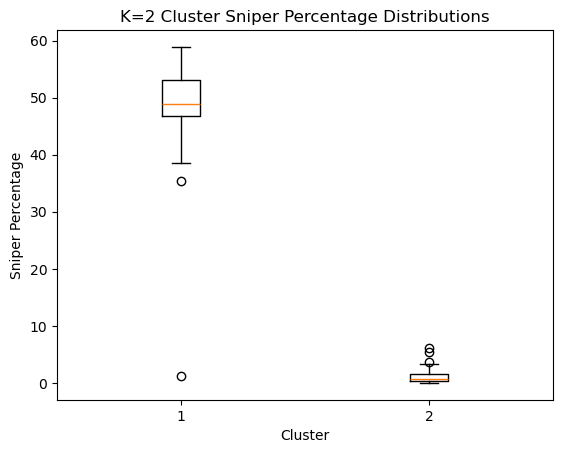

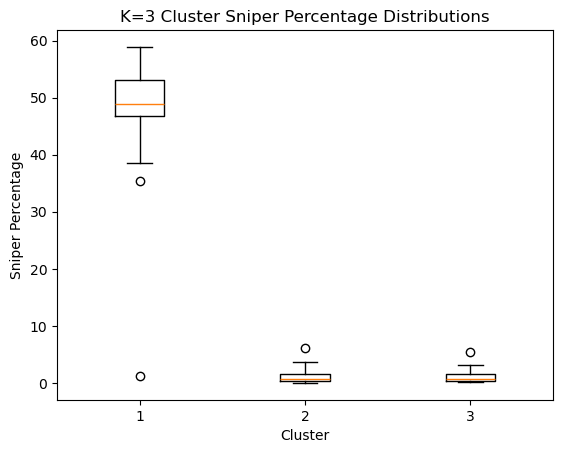

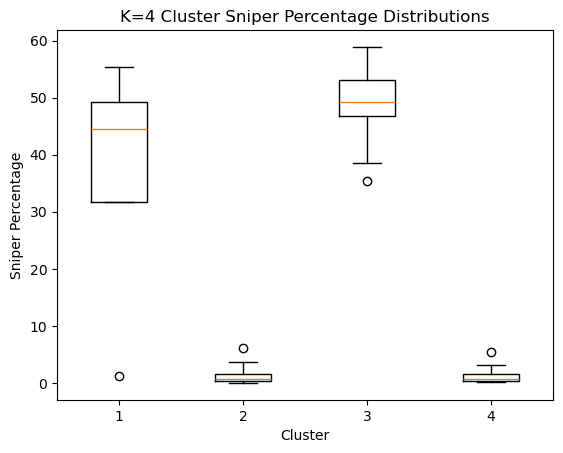

In [43]:
k2_sniper = [
    df2[df2["Cluster"] == c]["sniper_pct"]
    for c in sorted(df2["Cluster"].unique())
]

plt.boxplot(k2_sniper)
plt.title("K=2 Cluster Sniper Percentage Distributions")
plt.ylabel("Sniper Percentage")
plt.xlabel("Cluster")
plt.show()

k3_sniper = [
    df3[df3["Cluster"] == c]["sniper_pct"]
    for c in sorted(df3["Cluster"].unique())
]

plt.boxplot(k3_sniper)
plt.title("K=3 Cluster Sniper Percentage Distributions")
plt.ylabel("Sniper Percentage")
plt.xlabel("Cluster")
plt.show()

k4_sniper = [
    df4[df4["Cluster"] == c]["sniper_pct"]
    for c in sorted(df4["Cluster"].unique())
]

plt.boxplot(k4_sniper)
plt.title("K=4 Cluster Sniper Percentage Distributions")
plt.ylabel("Sniper Percentage")
plt.xlabel("Cluster")
plt.show()

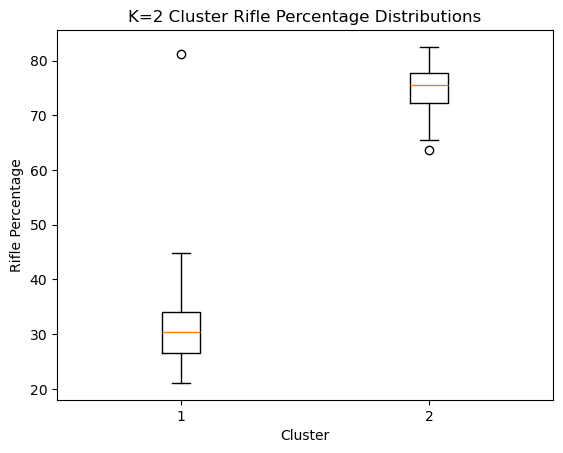

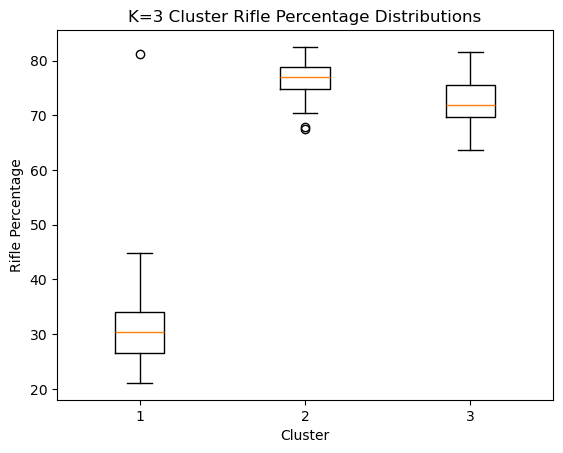

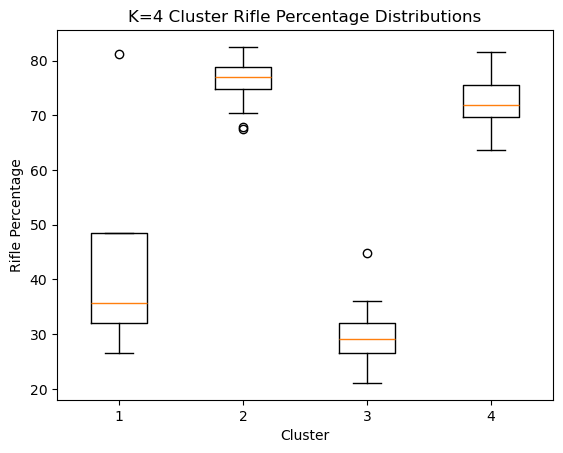

In [45]:
k2_rifle = [
    df2[df2["Cluster"] == c]["rifle_pct"]
    for c in sorted(df2["Cluster"].unique())
]

plt.boxplot(k2_rifle)
plt.title("K=2 Cluster Rifle Percentage Distributions")
plt.ylabel("Rifle Percentage")
plt.xlabel("Cluster")
plt.show()

k3_rifle = [
    df3[df3["Cluster"] == c]["rifle_pct"]
    for c in sorted(df3["Cluster"].unique())
]

plt.boxplot(k3_rifle)
plt.title("K=3 Cluster Rifle Percentage Distributions")
plt.ylabel("Rifle Percentage")
plt.xlabel("Cluster")
plt.show()

k4_rifle = [
    df4[df4["Cluster"] == c]["rifle_pct"]
    for c in sorted(df4["Cluster"].unique())
]

plt.boxplot(k4_rifle)
plt.title("K=4 Cluster Rifle Percentage Distributions")
plt.ylabel("Rifle Percentage")
plt.xlabel("Cluster")
plt.show()

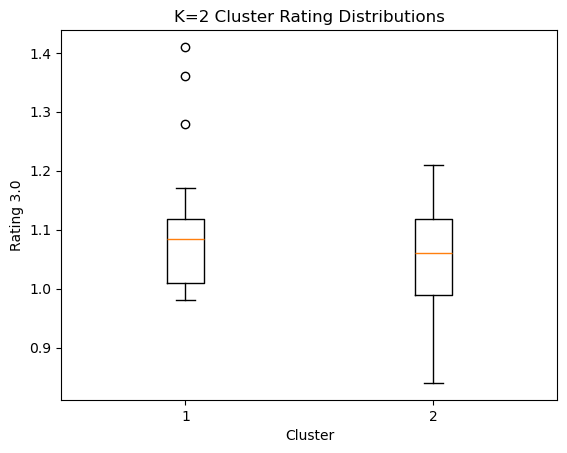

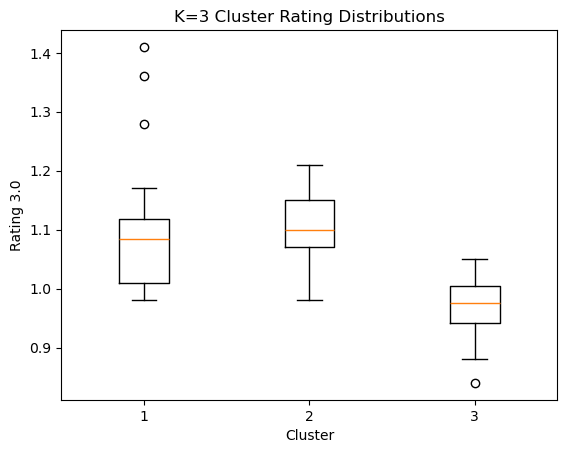

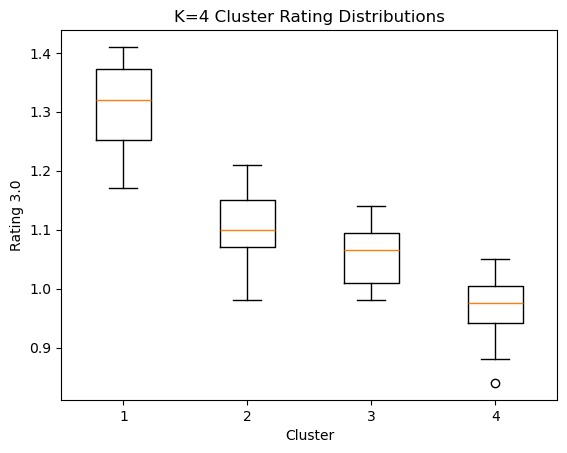

In [44]:

k2_rating = [
    df2[df2["Cluster"] == c]["RATING_3_0"]
    for c in sorted(df2["Cluster"].unique())
]

plt.boxplot(k2_rating)
plt.title("K=2 Cluster Rating Distributions")
plt.ylabel("Rating 3.0")
plt.xlabel("Cluster")
plt.show()

k3_rating = [
    df3[df3["Cluster"] == c]["RATING_3_0"]
    for c in sorted(df3["Cluster"].unique())
]

plt.boxplot(k3_rating)
plt.title("K=3 Cluster Rating Distributions")
plt.ylabel("Rating 3.0")
plt.xlabel("Cluster")
plt.show()

k4_rating = [
    df4[df4["Cluster"] == c]["RATING_3_0"]
    for c in sorted(df4["Cluster"].unique())
]

plt.boxplot(k4_rating)
plt.title("K=4 Cluster Rating Distributions")
plt.ylabel("Rating 3.0")
plt.xlabel("Cluster")
plt.show()